# 02 · Sampler anatomy

Six ways to steer a diffusion sampler, measured against exact targets. The
zoo, each with its one-line mechanism:

* **oracle**: draws from the exact posterior (the finite-N floor reference).
* **plug-in guidance (DPS-class)**: nudges each denoising step with the
  data gradient through a point estimate. Cheap, ubiquitous, no guarantee.
* **reward-as-potential SMC**: a particle population resampled every step on
  the reward. Improper by construction (the tilt compounds with depth).
* **twisted SMC**: the properly weighted particle method, with the optimal
  twist available in closed form on this bench.
* **terminal reweighting**: unguided samples, importance-reweighted once at
  the end.
* **inflated-noise annealed Langevin**: a ladder of noise levels with K
  Langevin corrections per level, the data pull deliberately weakened while
  the map is still noisy.

The measurement below is the squared Wasserstein distance to the exact
posterior, divided by the oracle floor, so 1.0 means indistinguishable from
perfect and 10 means ten times the unavoidable error.

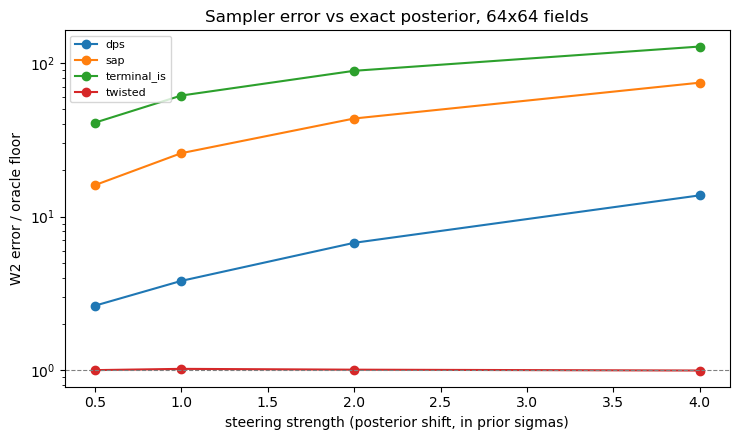

In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
RES = ROOT / "results"

def rows(name):
    p = RES / name
    if not p.exists():
        print(f"({name} not found, cell skipped)")
        return []
    return [json.loads(l) for l in p.open()]

t1 = [r for r in rows("t1_core.jsonl") if r.get("dim") == 64
      and r.get("eps", 0) == 0]
by = defaultdict(list)
floors = defaultdict(list)
for r in t1:
    if r["sampler"] == "oracle":
        floors[r["shift"]].append(r["w2"])
for r in t1:
    if r["sampler"] != "oracle":
        by[(r["sampler"], r["shift"])].append(r["w2"])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for s in sorted({k[0] for k in by}):
    shifts = sorted({k[1] for k in by if k[0] == s})
    ratios = [np.median(by[(s, sh)]) / np.median(floors[sh]) for sh in shifts]
    ax.plot(shifts, ratios, "o-", label=s)
ax.axhline(1, color="gray", lw=0.8, ls="--")
ax.set_yscale("log")
ax.set_xlabel("steering strength (posterior shift, in prior sigmas)")
ax.set_ylabel("W2 error / oracle floor")
ax.set_title("Sampler error vs exact posterior, 64x64 fields")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Reading the figure. The properly weighted method (twisted) sits on the
floor, as theory demands on this conjugate bench, which makes it the control
that validates the harness rather than a finding. Plug-in guidance is
substantially and monotonically biased, growing with steering strength. The
resampling shortcut and terminal reweighting degrade faster. The plug-in bias
curve was additionally confirmed by an independent closed-form calculation
(a stiff-ODE integration of the guided dynamics, matching the measured grid
to a few percent), so the mechanism is understood, not just observed.

## Misspecification, and the trap

Real deployments never have a perfect score. The bench can contaminate the
score in a controlled way (a spectral tilt of the prior, the analog of
baryonic-feedback systematics in cosmology) and watch how each scheme reacts.
One interaction matters most. Plug-in guidance is biased on its own, and the
score contamination can partially cancel that bias in the summary statistics
a practitioner would check first.

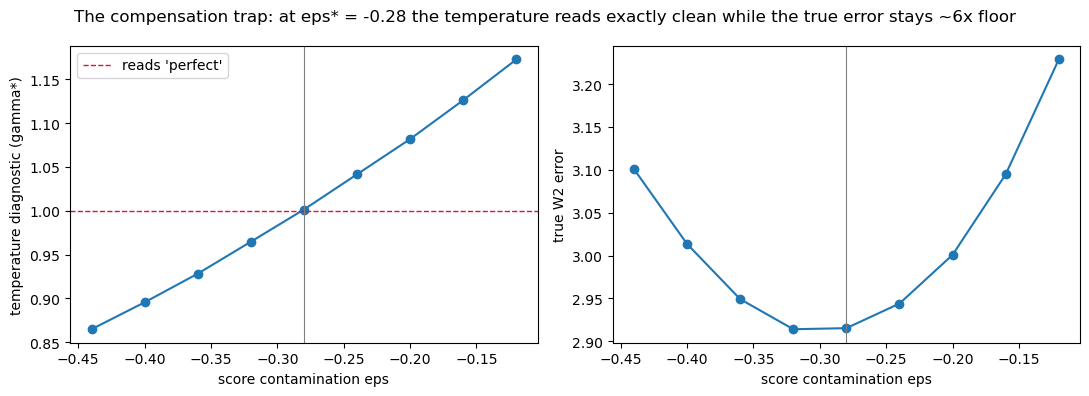

In [2]:
es = rows("eps_star.jsonl")
by_eps = defaultdict(lambda: defaultdict(list))
for r in es:
    if r["sampler"] == "dps":
        by_eps[r["eps"]]["g"].append(r["gamma_star"])
        by_eps[r["eps"]]["w"].append(r["w2"])
eps_grid = sorted(by_eps)
if eps_grid:
    g = [np.median(by_eps[e]["g"]) for e in eps_grid]
    w = [np.median(by_eps[e]["w"]) for e in eps_grid]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(eps_grid, g, "o-")
    axes[0].axhline(1.0, color="crimson", lw=1, ls="--",
                    label="reads 'perfect'")
    axes[0].set_xlabel("score contamination eps")
    axes[0].set_ylabel("temperature diagnostic (gamma*)")
    axes[0].legend()
    axes[1].plot(eps_grid, w, "o-")
    axes[1].set_xlabel("score contamination eps")
    axes[1].set_ylabel("true W2 error")
    for ax in axes:
        ax.axvline(-0.28, color="gray", lw=0.8)
    fig.suptitle("The compensation trap: at eps* = -0.28 the temperature "
                 "reads exactly clean while the true error stays ~6x floor")
    plt.tight_layout()
    plt.show()

This is the configuration used throughout notebook 03 as the hardest
test for the diagnostics: a doubly wrong pipeline (biased sampler, wrong
score) whose errors cancel in the statistic a person would check first. The
temperature diagnostic is fooled exactly. Sample-based tests do catch this
configuration, but they need several times more samples than usual. Whether
the proposed runtime certificates catch it is one of the questions the next
notebook answers.